# **02477 Bayesian Machine Learning — Exam 2025 Complete Guide**

Fully worked solutions for all 5 parts of the May 2025 exam, with step-by-step explanations of *why* each step is taken. Key formulas are highlighted in orange.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal as mvn

np.random.seed(42)


---
### **Part 1: A Linear Model for Regression**

Model:
$$y_n = f(x_n) + \epsilon_n, \quad \epsilon_n \sim \mathcal{N}(0, \sigma^2) \tag{1}$$
$$f(x_n) = w_0 + w_1 x_n + w_2 x_n^2 + w_3 x_n^3 = w^T\phi(x_n) \tag{2}$$

where $\phi(x_n) = [1,\ x_n,\ x_n^2,\ x_n^3]^T \in \mathbb{R}^4$, $w \in \mathbb{R}^4$.

Prior: $w_i \sim \mathcal{N}(0, 2)$ i.i.d. $\Rightarrow$ prior precision $\alpha = 1/2$.  Noise: $\sigma = 1/5$.

Data ($N=5$): $x = [0, 1, 2, 4, 5]$, $y = [1.0, 0.5, -0.1, -0.9, 1.1]$

In [2]:
# Part 1 setup
import numpy as np

x = np.array([0.0, 1.0, 2.0, 4.0, 5.0])
y = np.array([1.0, 0.5, -0.1, -0.9,  1.1])
N = len(x)

alpha = 1/2   # prior precision  (prior variance = 1/alpha = 2)
sigma = 1/5   # noise std dev

# Design matrix: each row is phi(x_n) = [1, x_n, x_n^2, x_n^3]
Phi = np.column_stack([np.ones(N), x, x**2, x**3])
print("Design matrix Phi (each row is phi(x_n)):")
print(np.array2string(Phi, precision=1))


Design matrix Phi (each row is phi(x_n)):
[[  1.   0.   0.   0.]
 [  1.   1.   1.   1.]
 [  1.   2.   4.   8.]
 [  1.   4.  16.  64.]
 [  1.   5.  25. 125.]]


##### **Question 1.1: Determine the analytical distribution $p(y|w, \Phi, \sigma^2)$.**

The model says $y_n = w^T\phi(x_n) + \epsilon_n$ with $\epsilon_n \sim \mathcal{N}(0,\sigma^2)$.

Rearranging: $y_n - w^T\phi(x_n) = \epsilon_n$, so conditioned on $w$, each $y_n$ is Gaussian centred at the prediction $w^T\phi(x_n)$:
$$p(y_n|w, \phi(x_n)) = \mathcal{N}(y_n|w^T\phi(x_n), \sigma^2)$$

Since the noise is i.i.d., all $N$ observations are conditionally independent given $w$. Stacking them into vectors, the product of $N$ Gaussians is a single multivariate Gaussian:

<span style="color: orange;">

$$\boxed{p(y|w, \Phi, \sigma^2) = \mathcal{N}(y|\Phi w, \sigma^2 I)}$$

</span>

Here $\Phi w$ is the vector of predictions $[w^T\phi(x_1), \ldots, w^T\phi(x_N)]^T$, and $\sigma^2 I$ says observations are independent with the same noise variance.

**This is the end of question 1.1.**

##### **Question 1.2: Compute the Maximum Likelihood Estimate (MLE) for $w$.**

The MLE maximises $p(y|w, \Phi, \sigma^2)$ over $w$, ignoring the prior. For a Gaussian likelihood, maximising it is the same as minimising $\|y - \Phi w\|^2$ (least squares).

Setting the gradient to zero gives the **Normal Equations**:

<span style="color: orange;">

$$\hat{w}_{\text{MLE}} = (\Phi^T\Phi)^{-1}\Phi^T y$$

</span>

**Derivation:** $\nabla_w \|y - \Phi w\|^2 = -2\Phi^T(y - \Phi w) = 0 \implies \Phi^T\Phi\,w = \Phi^T y$

Note: the MLE does not depend on $\sigma^2$ — scaling the noise doesn't change which $w$ fits the data best.

**This is the end of question 1.2.**

In [3]:
# Question 1.2 — MLE via Normal Equations
w_MLE = np.linalg.solve(Phi.T @ Phi, Phi.T @ y)
print(f"w_MLE = (Phi^T Phi)^-1 Phi^T y = {np.round(w_MLE, 2)}")
print()
# Verify: residuals should be small
resid = y - Phi @ w_MLE
print(f"Residuals y - Phi*w_MLE = {np.round(resid, 4)}")


w_MLE = (Phi^T Phi)^-1 Phi^T y = [ 0.95  0.27 -0.69  0.13]

Residuals y - Phi*w_MLE = [ 0.0466 -0.1555  0.1555 -0.0777  0.0311]


##### **Question 1.3: Determine the analytical posterior distribution $p(w|y)$.**

With a Gaussian prior $w \sim \mathcal{N}(0, \alpha^{-1}I)$ and Gaussian likelihood $p(y|w) = \mathcal{N}(y|\Phi w, \sigma^2 I)$, the model is **conjugate** — the posterior is also Gaussian.

This is a standard Bayesian linear regression result. Using Bayes' rule and completing the square:

<span style="color: orange;">

$$p(w|y) = \mathcal{N}(w|m, S)$$
$$S = \left(\alpha I + \frac{1}{\sigma^2}\Phi^T\Phi\right)^{-1} \tag{post-cov}$$
$$m = \frac{1}{\sigma^2} S \Phi^T y \tag{post-mean}$$

</span>

**Intuition:**
- $S^{-1} = \alpha I + \frac{1}{\sigma^2}\Phi^T\Phi$: the posterior precision is the **sum** of prior precision ($\alpha I$) and likelihood precision ($\frac{1}{\sigma^2}\Phi^T\Phi$). More data $\Rightarrow$ smaller posterior variance.
- $m$: weighted combination of prior (zero) and data signal $\Phi^T y$, scaled by precision $1/\sigma^2$.
- With prior variance $\alpha^{-1} = 2$ and small $\sigma = 1/5$, the data dominates so $m \approx w_{\text{MLE}}$.

**This is the end of question 1.3.**

In [4]:
# Question 1.3 — Bayesian posterior
S_inv = alpha * np.eye(4) + (1/sigma**2) * Phi.T @ Phi   # posterior precision
S     = np.linalg.inv(S_inv)                              # posterior covariance
m     = (1/sigma**2) * S @ Phi.T @ y                     # posterior mean

print("Posterior p(w|y) = N(w | m, S)")
print()
print(f"Posterior mean m = {np.round(m, 2)}")
print(f"  (Compare MLE:  {np.round(w_MLE, 2)} — very close due to informative data)")
print()
print("Posterior covariance S:")
print(np.array2string(S, precision=2))
print()
print("Note: diagonal entries of S are small -> tight posterior (data is very informative)")


Posterior p(w|y) = N(w | m, S)

Posterior mean m = [ 0.95  0.25 -0.68  0.13]
  (Compare MLE:  [ 0.95  0.27 -0.69  0.13] — very close due to informative data)

Posterior covariance S:
[[ 0.04 -0.04  0.01 -0.  ]
 [-0.04  0.13 -0.06  0.01]
 [ 0.01 -0.06  0.04 -0.  ]
 [-0.    0.01 -0.    0.  ]]

Note: diagonal entries of S are small -> tight posterior (data is very informative)


##### **Question 1.4: Determine the posterior predictive distribution $p(y^*|y, x^*)$ for $x^*=3$.**

The **posterior predictive** distribution for a new input $x^*$ integrates out the uncertainty in $w$:
$$p(y^*|y, x^*) = \int p(y^*|w, x^*)\,p(w|y)\,dw$$

Since both the likelihood and posterior are Gaussian, this integral is analytically tractable. The result is a Gaussian:

<span style="color: orange;">

$$p(y^*|y, x^*) = \mathcal{N}(y^*|m^T\phi^*,\; (\phi^*)^T S\,\phi^* + \sigma^2)$$

</span>

The variance has two parts:
- $(\phi^*)^T S\,\phi^*$: **epistemic uncertainty** — our uncertainty about $w$ propagated to the prediction
- $\sigma^2$: **aleatoric uncertainty** — irreducible observation noise

At $x^*=3$: $\phi^* = [1, 3, 9, 27]^T$

**This is the end of question 1.4.**

In [5]:
# Question 1.4 — Posterior predictive at x* = 3
xstar    = 3.0
phi_star = np.array([1, xstar, xstar**2, xstar**3])   # [1, 3, 9, 27]

pred_mean = m @ phi_star                               # m^T phi*
pred_var  = phi_star @ S @ phi_star + sigma**2         # phi*^T S phi* + sigma^2

print(f"phi* = {phi_star}")
print()
print(f"Predictive mean    = m^T phi*              = {pred_mean:.2f}")
print(f"Epistemic variance = phi*^T S phi*         = {phi_star @ S @ phi_star:.4f}")
print(f"Aleatoric variance = sigma^2               = {sigma**2:.4f}")
print(f"Predictive variance                        = {pred_var:.2f}")
print()
print(f"p(y*|y, x*=3) = N(y*| {pred_mean:.2f}, {pred_var:.2f})")


phi* = [ 1.  3.  9. 27.]

Predictive mean    = m^T phi*              = -1.00
Epistemic variance = phi*^T S phi*         = 0.0340
Aleatoric variance = sigma^2               = 0.0400
Predictive variance                        = 0.07

p(y*|y, x*=3) = N(y*| -1.00, 0.07)


---
### **Part 2: Grid Approximation for Non-linear Regression**

Model likelihood: $p(y_n|w, x_n) = \mathcal{N}(y_n|f(x_n), \sigma^2)$ where $f(x_n) = e^{w_1 + w_2 x_n}$ and $\sigma^2 = 1/2$.

The grid approximation $q(w)$ of the posterior $p(w|y)$ is given in Figure 1. Non-zero entries:

| $w_1$ | $w_2$ | $q(w_1, w_2)$ |
|-------|-------|--------------|
| 0.5   | 0.2   | 0.12         |
| 0.5   | 0.3   | 0.09         |
| 0.6   | 0.1   | 0.12         |
| 0.6   | 0.2   | 0.20         |
| 0.6   | 0.3   | 0.12         |
| 0.7   | 0.1   | 0.23         |
| 0.7   | 0.2   | 0.12         |

Note: the probabilities sum to $0.12+0.09+0.12+0.20+0.12+0.23+0.12 = 1.00$ ✓

In [6]:
# Part 2 setup — grid of non-zero posterior probabilities
# Each row: (w1, w2, q(w1,w2))
grid = np.array([
    (0.5, 0.2, 0.12),
    (0.5, 0.3, 0.09),
    (0.6, 0.1, 0.12),
    (0.6, 0.2, 0.20),
    (0.6, 0.3, 0.12),
    (0.7, 0.1, 0.23),
    (0.7, 0.2, 0.12),
])
w1s, w2s, probs = grid[:, 0], grid[:, 1], grid[:, 2]
print(f"Sum of probabilities: {probs.sum():.2f}  (should be 1.00)")

sigma2_2 = 0.5  # noise variance for Part 2
f_model  = lambda w1, w2, x: np.exp(w1 + w2*x)


Sum of probabilities: 1.00  (should be 1.00)


##### **Question 2.1: Estimate the posterior mean and variance of $w_1$ using the grid.**

The grid approximation gives us a **discrete probability distribution** over $(w_1, w_2)$ pairs. To get the marginal distribution of $w_1$, we sum over all $w_2$ values (marginalisation):

$$q(w_1 = v) = \sum_{w_2} q(w_1=v, w_2)$$

Then the posterior mean and variance are the standard discrete expectations:

<span style="color: orange;">

$$\mathbb{E}[w_1|y] \approx \sum_{w_1, w_2} w_1 \cdot q(w_1, w_2) \tag{discrete mean}$$
$$\mathbb{V}[w_1|y] \approx \sum_{w_1, w_2} (w_1 - \mathbb{E}[w_1|y])^2 \cdot q(w_1, w_2) \tag{discrete variance}$$

</span>

**Manual computation for the mean:**
$$\mathbb{E}[w_1] = 0.5 \times (0.12+0.09) + 0.6 \times (0.12+0.20+0.12) + 0.7 \times (0.23+0.12)$$
$$= 0.5 \times 0.21 + 0.6 \times 0.44 + 0.7 \times 0.35 = 0.105 + 0.264 + 0.245 = 0.61$$

**This is the end of question 2.1.**

In [7]:
# Question 2.1 — Posterior mean and variance of w1
mean_w1 = np.sum(w1s * probs)
var_w1  = np.sum((w1s - mean_w1)**2 * probs)
std_w1  = np.sqrt(var_w1)

print("Manual breakdown of E[w1]:")
for v in [0.5, 0.6, 0.7]:
    mass = probs[w1s == v].sum()
    print(f"  w1={v}: sum of q = {mass:.2f}, contribution = {v}*{mass:.2f} = {v*mass:.3f}")
print()
print(f"E[w1 | y]  = {mean_w1:.2f}")
print(f"Var[w1|y]  = {var_w1:.2f}")
print(f"Std[w1|y]  = sqrt(Var) = {std_w1:.2f}")


Manual breakdown of E[w1]:
  w1=0.5: sum of q = 0.21, contribution = 0.5*0.21 = 0.105
  w1=0.6: sum of q = 0.44, contribution = 0.6*0.44 = 0.264
  w1=0.7: sum of q = 0.35, contribution = 0.7*0.35 = 0.245

E[w1 | y]  = 0.61
Var[w1|y]  = 0.01
Std[w1|y]  = sqrt(Var) = 0.07


##### **Question 2.2: Estimate $p(y^*=4|y, x^*=4)$ using the grid.**

The **posterior predictive** probability marginalises over the grid:
$$p(y^*|y, x^*) = \int p(y^*|w, x^*)\,p(w|y)\,dw \approx \sum_{w_1, w_2} p(y^*|w_1, w_2, x^*)\,q(w_1, w_2)$$

<span style="color: orange;">

$$p(y^*=4|y, x^*=4) \approx \sum_{w_1, w_2} \mathcal{N}\!\left(4\;\Big|\;e^{w_1 + w_2 \cdot 4},\; \tfrac{1}{2}\right) \cdot q(w_1, w_2)$$

</span>

This is a **weighted average** of Gaussian likelihoods — each grid point predicts a slightly different mean $e^{w_1+4w_2}$, and we weight each prediction by the posterior probability of that parameter pair.

**Step 1** — For each $(w_1, w_2)$, compute $\mu_{w_1,w_2} = e^{w_1 + 4w_2}$ (predicted function value at $x^*=4$).

**Step 2** — Evaluate $\mathcal{N}(4|\mu_{w_1,w_2}, 0.5)$ (how likely is $y^*=4$ under this prediction?).

**Step 3** — Multiply by $q(w_1, w_2)$ and sum.

**This is the end of question 2.2.**

In [8]:
# Question 2.2 — Posterior predictive p(y*=4 | y, x*=4)
y_star = 4.0
x_star = 4.0

log_npdf = lambda y, mu, v: -0.5*(y-mu)**2/v - 0.5*np.log(2*np.pi*v)
npdf     = lambda y, mu, v: np.exp(log_npdf(y, mu, v))

print("Contribution of each grid point:")
post_pred = 0.0
for w1, w2, p in grid:
    mu_pred = f_model(w1, w2, x_star)              # e^{w1 + w2*x*}
    lik     = npdf(y_star, mu_pred, sigma2_2)       # N(y*=4 | mu, 0.5)
    contrib = lik * p
    post_pred += contrib
    print(f"  w1={w1}, w2={w2}: mu=e^{{{w1}+{w2}*4}}={mu_pred:.3f}, "
          f"N(4|{mu_pred:.2f},0.5)={lik:.4f}, *q={contrib:.4f}")

print()
print(f"p(y*=4 | y, x*=4) = sum over grid = {post_pred:.2f}")


Contribution of each grid point:
  w1=0.5, w2=0.2: mu=e^{0.5+0.2*4}=3.669, N(4|3.67,0.5)=0.5057, *q=0.0607
  w1=0.5, w2=0.3: mu=e^{0.5+0.3*4}=5.474, N(4|5.47,0.5)=0.0643, *q=0.0058
  w1=0.6, w2=0.1: mu=e^{0.6+0.1*4}=2.718, N(4|2.72,0.5)=0.1091, *q=0.0131
  w1=0.6, w2=0.2: mu=e^{0.6+0.2*4}=4.055, N(4|4.06,0.5)=0.5625, *q=0.1125
  w1=0.6, w2=0.3: mu=e^{0.6+0.3*4}=6.050, N(4|6.05,0.5)=0.0085, *q=0.0010
  w1=0.7, w2=0.1: mu=e^{0.7+0.1*4}=3.004, N(4|3.00,0.5)=0.2093, *q=0.0481
  w1=0.7, w2=0.2: mu=e^{0.7+0.2*4}=4.482, N(4|4.48,0.5)=0.4474, *q=0.0537

p(y*=4 | y, x*=4) = sum over grid = 0.29


---
### **Part 3: A Mixture Model**

Likelihood (mixture): $p(y_n|\theta, x_n, z_n) = (1-z_n)\mathcal{N}(y_n|0,1) + z_n\mathcal{N}(y_n|\theta^T x_n, \sigma^2)$

where $z_n \in \{0,1\}$ is a binary switch, $\sigma^2 = 1/10$.

Priors: $\theta \sim \mathcal{N}(0, \alpha^{-1}I)$ with $\alpha=1/2$, and $z_n \sim \text{Ber}(\pi)$ with $\pi=4/5$.

Single observation: $N=1$, $x_1=[1,1]^T$, $y_1=1$.

Optimal mean-field approximation: $q_1^*(\theta) = \mathcal{N}(\theta_1|m_1,v_1)\mathcal{N}(\theta_2|m_2,v_2)$ with $m_1=m_2=1/4$, $v_1=v_2=6/5$.

In [9]:
# Part 3 setup
import numpy as np
from scipy.stats import norm, multivariate_normal as mvn

pi     = 4/5
alpha  = 1/2
sigma2 = 1/10
x1     = np.array([1.0, 1.0])
y1     = 1.0

# Optimal variational parameters
m1, m2 = 1/4, 1/4
v1, v2 = 6/5, 6/5


##### **Question 3.1: Determine $p(y_1, \theta)$ analytically.**

We marginalise the joint $p(y_1, z_1, \theta)$ over $z_1 \in \{0, 1\}$ using the sum rule.

The joint is:
$$p(y_1, z_1, \theta) = p(y_1|\theta, z_1)\,p(z_1)\,p(\theta)$$

**Marginalising over $z_1$:**
$$p(y_1, \theta) = \sum_{z_1 \in \{0,1\}} p(y_1|\theta, z_1)\,\text{Ber}(z_1|\pi)\,\mathcal{N}(\theta|0,\alpha^{-1}I)$$

For $z_1=0$ (with probability $1-\pi$): $p(y_1|\theta, z_1=0) = \mathcal{N}(y_1|0, 1)$ — does not depend on $\theta$!

For $z_1=1$ (with probability $\pi$): $p(y_1|\theta, z_1=1) = \mathcal{N}(y_1|\theta^T x_1, \sigma^2)$

So:
<span style="color: orange;">
$$\boxed{p(y_1, \theta) = (1-\pi)\,\mathcal{N}(y_1|0,1)\,\mathcal{N}(\theta|0,\alpha^{-1}I) + \pi\,\mathcal{N}(y_1|\theta^T x_1,\sigma^2)\,\mathcal{N}(\theta|0,\alpha^{-1}I)}$$
</span>

Interpretation: a mixture of two terms — one where the observation comes from noise ($z_1=0$) and one where it comes from the linear model ($z_1=1$).

**This is the end of question 3.1.**

##### **Question 3.2: Determine $p(y_1, z_1)$ analytically.**

Now we marginalise over $\theta$ using the sum rule and the **linear Gaussian marginalisation** formula.

$$p(y_1, z_1) = \int p(y_1, z_1, \theta)\,d\theta = \int p(y_1|\theta, z_1)\,p(z_1)\,p(\theta)\,d\theta$$

For the $z_1=0$ term: $\int \mathcal{N}(y_1|0,1)\,\mathcal{N}(\theta|0,\alpha^{-1}I)\,d\theta = \mathcal{N}(y_1|0,1) \cdot 1$ (prior integrates to 1).

For the $z_1=1$ term: $\int \mathcal{N}(y_1|\theta^T x_1,\sigma^2)\,\mathcal{N}(\theta|0,\alpha^{-1}I)\,d\theta$. This uses the linear Gaussian marginalisation formula with $W = x_1^T$, $\mu_z=0$, $\Sigma_z = \alpha^{-1}I$, $\Sigma_y = \sigma^2$:

$$= \mathcal{N}(y_1|x_1^T \cdot 0, \sigma^2 + \alpha^{-1}x_1^T x_1) = \mathcal{N}(y_1|0, \sigma^2 + \alpha^{-1}\|x_1\|^2)$$

With $\|x_1\|^2 = 1^2 + 1^2 = 2$ and $\alpha^{-1} = 2$: variance $= 1/10 + 2 \cdot 2 = 1/10 + 4 = 41/10$.

<span style="color: orange;">

$$\boxed{p(y_1, z_1) = \left[(1-z_1)\mathcal{N}(y_1|0,1) + z_1\,\mathcal{N}\!\left(y_1|0,\; \sigma^2 + \alpha^{-1}x_1^T x_1\right)\right]\text{Ber}(z_1|\pi)}$$

</span>

**This is the end of question 3.2.**

In [10]:
# Question 3.2 — verify the marginal variance for the z1=1 term
alpha_inv = 1/alpha
marginal_var = sigma2 + alpha_inv * x1 @ x1

print("Marginal p(y1, z1) computation:")
print(f"  ||x1||^2 = {x1 @ x1:.1f}")
print(f"  alpha^-1 = {alpha_inv:.1f}")
print(f"  Marginal variance (z1=1 term) = sigma^2 + alpha^-1 * ||x1||^2")
print(f"    = {sigma2} + {alpha_inv} * {x1@x1} = {marginal_var:.2f}")
print()

# Evaluate at y1=1 for both z1 values
for z in [0, 1]:
    if z == 0:
        lik_val = norm.pdf(y1, 0, 1)
        bern    = 1 - pi
    else:
        lik_val = norm.pdf(y1, 0, np.sqrt(marginal_var))
        bern    = pi
    print(f"  z1={z}: N(y1=1 | 0, {'1' if z==0 else f'{marginal_var:.2f}'}) * Ber({z}|pi) "
          f"= {lik_val:.4f} * {bern:.2f} = {lik_val*bern:.4f}")


Marginal p(y1, z1) computation:
  ||x1||^2 = 2.0
  alpha^-1 = 2.0
  Marginal variance (z1=1 term) = sigma^2 + alpha^-1 * ||x1||^2
    = 0.1 + 2.0 * 2.0 = 4.10

  z1=0: N(y1=1 | 0, 1) * Ber(0|pi) = 0.2420 * 0.20 = 0.0484
  z1=1: N(y1=1 | 0, 4.10) * Ber(1|pi) = 0.1744 * 0.80 = 0.1395


##### **Question 3.3: Compute the entropy of $q_1^*(\theta)$.**

The variational approximation $q_1^*(\theta) = \mathcal{N}(\theta_1|m_1,v_1)\mathcal{N}(\theta_2|m_2,v_2)$ is a **mean-field** (factorised) Gaussian. Since the factors are independent, the entropy adds:
$$H[q_1^*] = H[q(\theta_1)] + H[q(\theta_2)]$$

The entropy of a univariate Gaussian $\mathcal{N}(m, v)$ is:
<span style="color: orange;">
$$H[\mathcal{N}(m, v)] = \frac{1}{2}\ln(2\pi e v)$$
</span>

Note: entropy depends only on variance $v$, not the mean $m$. With $v_1 = v_2 = 6/5$:
$$H[q_1^*] = \frac{1}{2}\ln\!\left(2\pi e \cdot \frac{6}{5}\right) + \frac{1}{2}\ln\!\left(2\pi e \cdot \frac{6}{5}\right) = \ln\!\left(2\pi e \cdot \frac{6}{5}\right) \approx 3.02$$

**This is the end of question 3.3.**

In [11]:
# Question 3.3 — Entropy of q*1(theta)
H_each = 0.5 * np.log(2 * np.pi * np.e * v1)  # entropy of each 1D factor
H_total = H_each + 0.5 * np.log(2 * np.pi * np.e * v2)  # sum (v1=v2 so doubles)

print(f"H[N(theta_1 | m1, v1)] = 0.5*ln(2*pi*e*{v1}) = {H_each:.4f}")
print(f"H[N(theta_2 | m2, v2)] = 0.5*ln(2*pi*e*{v2}) = {H_each:.4f}  (same, v1=v2)")
print()
print(f"H[q*1(theta)] = H[q(theta1)] + H[q(theta2)] = {H_total:.2f}")
print()
print(f"Equivalent form: ln(2*pi*e*6/5) = {np.log(2*np.pi*np.e*6/5):.2f}")


H[N(theta_1 | m1, v1)] = 0.5*ln(2*pi*e*1.2) = 1.5101
H[N(theta_2 | m2, v2)] = 0.5*ln(2*pi*e*1.2) = 1.5101  (same, v1=v2)

H[q*1(theta)] = H[q(theta1)] + H[q(theta2)] = 3.02

Equivalent form: ln(2*pi*e*6/5) = 3.02


##### **Question 3.4: Compute a 95% credibility interval for $q_1^*(\theta_2)$.**

The marginal distribution of $\theta_2$ under the variational approximation is:
$$q_1^*(\theta_2) = \mathcal{N}(\theta_2|m_2, v_2) = \mathcal{N}\!\left(\theta_2\;\Big|\;\frac{1}{4},\ \frac{6}{5}\right)$$

A **95% credibility interval** has 2.5% probability mass in each tail. For a Gaussian, this uses the 97.5th percentile of the standard normal, which is $z_{0.975} = 1.96$:

<span style="color: orange;">

$$\left[m_2 - 1.96\sqrt{v_2},\; m_2 + 1.96\sqrt{v_2}\right]$$

</span>

**Important:** $v_2 = 6/5$ is the **variance**, so we need $\sqrt{v_2}$ as the standard deviation.

$$\left[\frac{1}{4} - 1.96\sqrt{\frac{6}{5}},\; \frac{1}{4} + 1.96\sqrt{\frac{6}{5}}\right] \approx [0.25 - 2.15, 0.25 + 2.15] \approx [-1.90, 2.40]$$

**This is the end of question 3.4.**

In [12]:
# Question 3.4 — 95% credibility interval for theta2
z_975   = 1.96                   # 97.5th percentile of standard normal
std_2   = np.sqrt(v2)            # standard deviation (v2 is variance!)

lower   = m2 - z_975 * std_2
upper   = m2 + z_975 * std_2

print(f"q*1(theta2) = N(theta2 | {m2}, {v2})")
print(f"  std = sqrt({v2}) = {std_2:.4f}")
print()
print(f"95% interval = [m2 - 1.96*std, m2 + 1.96*std]")
print(f"             = [{m2} - 1.96*{std_2:.4f}, {m2} + 1.96*{std_2:.4f}]")
print(f"             = [{lower:.2f}, {upper:.2f}]")

# Verify using scipy
lower_sc, upper_sc = norm.interval(0.95, loc=m2, scale=std_2)
print(f"  (scipy check: [{lower_sc:.2f}, {upper_sc:.2f}])")


q*1(theta2) = N(theta2 | 0.25, 1.2)
  std = sqrt(1.2) = 1.0954

95% interval = [m2 - 1.96*std, m2 + 1.96*std]
             = [0.25 - 1.96*1.0954, 0.25 + 1.96*1.0954]
             = [-1.90, 2.40]
  (scipy check: [-1.90, 2.40])


##### **Question 3.5: Determine the approximate posterior predictive $p(y^*|y, x^*)$ for $x^*=[-1,3]^T$.**

With $p(\theta|y) \approx q_1^*(\theta) = \mathcal{N}(\theta|m, V)$ where $m = \frac{1}{4}[1,1]^T$ and $V = \frac{6}{5}I$, the posterior predictive is:
$$p(y^*|y, x^*) = \int p(y^*|\theta, x^*)\,q_1^*(\theta)\,d\theta$$

The likelihood $p(y^*|\theta, x^*)$ is itself a mixture (same form as the original model):
$$p(y^*|\theta, x^*) = (1-\pi)\mathcal{N}(y^*|0,1) + \pi\mathcal{N}(y^*|\theta^T x^*, \sigma^2)$$

Substituting and integrating:
- First term: $(1-\pi)\mathcal{N}(y^*|0,1)\int q_1^*(\theta)\,d\theta = (1-\pi)\mathcal{N}(y^*|0,1)$
- Second term: $\pi \int \mathcal{N}(y^*|\theta^T x^*, \sigma^2)\,\mathcal{N}(\theta|m, V)\,d\theta$

The second integral is linear Gaussian marginalisation with $W = (x^*)^T$:
$$= \pi\,\mathcal{N}(y^*|(x^*)^T m,\ \sigma^2 + (x^*)^T V x^*)$$

Computing: $(x^*)^T m = [-1,3]\cdot\frac{1}{4}[1,1]^T = \frac{-1+3}{4} = \frac{1}{2}$

$(x^*)^T V x^* = \frac{6}{5}\|x^*\|^2 = \frac{6}{5}(1+9) = \frac{60}{5} = 12$

<span style="color: orange;">

$$\boxed{p(y^*|y,x^*) = \frac{1}{5}\mathcal{N}(y^*|0,1) + \frac{4}{5}\mathcal{N}\!\left(y^*\;\Big|\;\frac{1}{2},\ \frac{1}{10}+12\right)}$$

</span>

**This is the end of question 3.5.**

In [13]:
# Question 3.5 — Posterior predictive at x* = [-1, 3]
x_star3 = np.array([-1.0, 3.0])
m_vec   = np.array([m1, m2])           # [1/4, 1/4]
V_mat   = np.diag([v1, v2])            # diag(6/5, 6/5)

# Mean of predictive for z*=1 term
pred_mean3 = x_star3 @ m_vec
print(f"x* = {x_star3}")
print(f"m  = {m_vec}")
print(f"(x*)^T m = {x_star3} . {m_vec} = {pred_mean3:.4f} = 1/2")
print()

# Variance of predictive for z*=1 term
pred_var3 = sigma2 + x_star3 @ V_mat @ x_star3
print(f"(x*)^T V x* = {v1}*||x*||^2 = {v1}*{x_star3@x_star3} = {v1*x_star3@x_star3:.1f}")
print(f"Predictive variance = sigma^2 + (x*)^T V x* = {sigma2} + {v1*x_star3@x_star3:.1f} = {pred_var3:.2f}")
print()
print(f"p(y*|y, x*) = (1-pi)*N(y*|0,1) + pi*N(y*| {pred_mean3:.2f}, {pred_var3:.2f})")
print(f"           = (1/5)*N(y*|0,1)   + (4/5)*N(y*| 1/2, {pred_var3:.2f})")


x* = [-1.  3.]
m  = [0.25 0.25]
(x*)^T m = [-1.  3.] . [0.25 0.25] = 0.5000 = 1/2

(x*)^T V x* = 1.2*||x*||^2 = 1.2*10.0 = 12.0
Predictive variance = sigma^2 + (x*)^T V x* = 0.1 + 12.0 = 12.10

p(y*|y, x*) = (1-pi)*N(y*|0,1) + pi*N(y*| 0.50, 12.10)
           = (1/5)*N(y*|0,1)   + (4/5)*N(y*| 1/2, 12.10)


##### **Question 3.6: How does the KL divergence change when switching from $q_1^*$ to $q_2^*$?**

$Q_1$ is the **mean-field Gaussian** family (diagonal covariance).
$Q_2$ is the **full-rank Gaussian** family (arbitrary covariance matrix).

The key observation is that every mean-field Gaussian is also a full-rank Gaussian (a diagonal covariance matrix is a special case of any covariance matrix). Therefore:
$$Q_1 \subset Q_2$$

$Q_2$ is a **strictly larger** family — it contains $Q_1$ plus all non-diagonal Gaussians.

Since $q_2^*$ minimises the KL over a larger set that includes $q_1^*$ as a special case:

<span style="color: orange;">

$$\text{KL}[q_2^*(\theta)\|p(\theta|y_1)] \leq \text{KL}[q_1^*(\theta)\|p(\theta|y_1)]$$

</span>

The KL divergence **decreases** (or stays the same). The full-rank family can capture posterior correlations that the mean-field approximation cannot, so it can get strictly closer to the true posterior.

Intuitively: $q_1^*$ forces $\theta_1 \perp \theta_2$, but the true posterior may have correlated parameters (if the observation $y_1 = \theta_1 + \theta_2 \approx 1$ creates a negative correlation between them). $q_2^*$ can capture this.

---
### **Part 4: Gaussian Process Classification**

Model:
$$f(x) \sim \mathcal{GP}(0, k_1(x,x')), \quad y_n|f_n \sim \text{Ber}(\sigma(f(x_n)))$$

Kernel: $k_1(x,x') = 5\left(1 + \exp\!\left(-\frac{1}{4}(x-x')^2\right)\right)$

Data: $x=[1,2,3]$, $y=[1,1,0]$, test point $x^*=4$.

Laplace approximation: $q(f) = \mathcal{N}(f|m, S)$ with given $m$ and $S$.

In [14]:
# Part 4 setup
import numpy as np
from scipy.stats import norm

x4 = np.array([1.0, 2.0, 3.0])[:, None]   # (3,1)
y4 = np.array([1.0, 1.0, 0.0])[:, None]
x_star4 = np.array([[4.0]])                 # (1,1)

m4 = np.array([1.56,  0.84, -0.32])
S4 = np.array([[2.69, 1.46, 0.42],
               [1.46, 1.78, 1.20],
               [0.42, 1.20, 2.13]])

# Kernel k1(x, x') = 5*(1 + exp(-1/4*(x-x')^2))
def k1(x1, x2):
    """Compute kernel matrix. x1: (N,1), x2: (M,1). Returns (N,M)."""
    dist_sq = (x1 - x2.T)**2    # broadcasts to (N,M)
    return 5.0 * (1.0 + np.exp(-0.25 * dist_sq))

K4  = k1(x4, x4) + 1e-8*np.eye(3)   # prior cov at training points (with jitter)
k_s = k1(x_star4, x4)                # (1,3) cross-covariance
k_ss= k1(x_star4, x_star4)           # (1,1) prior variance at x*

print(f"Prior variance at x*=4: k1(4,4) = 5*(1 + exp(0)) = 5*(1+1) = {k_ss[0,0]:.2f}")


Prior variance at x*=4: k1(4,4) = 5*(1 + exp(0)) = 5*(1+1) = 10.00


##### **Question 4.1: Determine the analytical prior distribution $p(f^*)$.**

The GP prior states that any function value is Gaussian with mean 0 and variance given by the kernel:
$$p(f^*) = \mathcal{N}(f^*|0, k_1(x^*, x^*))$$

At $x^* = x^{*'}$, the distance is zero:
$$k_1(4, 4) = 5\left(1 + \exp\!\left(-\frac{1}{4}(4-4)^2\right)\right) = 5(1 + \exp(0)) = 5(1+1) = 10$$

$$\boxed{p(f^*) = \mathcal{N}(f^*|0, 10)}$$

**This is the end of question 4.1.**

##### **Question 4.2: Compute the prior predictive probability $p(y^*=0|x^*)$.**

The prior predictive integrates the Bernoulli likelihood over the GP prior on $f^*$:
$$p(y^*=0|x^*) = \int p(y^*=0|f^*)\,p(f^*)\,df^* = \int (1 - \sigma(f^*))\,\mathcal{N}(f^*|0,10)\,df^*$$

**Key insight:** The GP prior has **mean zero** and $p(f^*) = \mathcal{N}(f^*|0,10)$ is symmetric around 0. The sigmoid satisfies $\sigma(-a) = 1 - \sigma(a)$.

Therefore, for every positive $f^*$ with probability $p$, there is a corresponding $-f^*$ with the same probability, but $p(y^*=1|-f^*) = \sigma(-f^*) = 1-\sigma(f^*) = p(y^*=0|f^*)$.

By symmetry, the expected probability of each class must be exactly 0.5:

$$\boxed{p(y^*=0|x^*=4) = 0.5}$$

**This is the end of question 4.2.**

In [15]:
# Question 4.2 — verify by Monte Carlo
np.random.seed(0)
f_samples = np.random.normal(0, np.sqrt(10), size=1_000_000)   # f* ~ N(0, 10)
sigmoid   = lambda f: 1/(1+np.exp(-f))

p_y0_mc = np.mean(1 - sigmoid(f_samples))   # p(y*=0) = E[1 - sigma(f*)]
print(f"MC estimate of p(y*=0 | x*=4) = {p_y0_mc:.4f}")
print(f"Exact by symmetry: 0.5000")
print()
print("Reasoning: p(f*) = N(0, 10) is symmetric around 0,")
print("and sigma(-f) = 1 - sigma(f), so E[1-sigma(f*)] = E[sigma(-f*)] = E[sigma(f*)] = 0.5")


MC estimate of p(y*=0 | x*=4) = 0.4993
Exact by symmetry: 0.5000

Reasoning: p(f*) = N(0, 10) is symmetric around 0,
and sigma(-f) = 1 - sigma(f), so E[1-sigma(f*)] = E[sigma(-f*)] = E[sigma(f*)] = 0.5


##### **Question 4.3: Compute the approximate posterior $p(f^*|y, x^*)$ using the Laplace approximation.**

Using the Laplace approximation $p(f|y) \approx q(f) = \mathcal{N}(f|m, S)$, we apply the **GP posterior prediction equations** (which come from the linear Gaussian framework):

<span style="color: orange;">

$$\mu_{f^*|y} = k^T K^{-1} m \tag{posterior mean}$$
$$\sigma^2_{f^*|y} = k(x^*,x^*) - k^T K^{-1}(K - S)K^{-1}k \tag{posterior variance}$$

</span>

where:
- $k = [k_1(x^*, x_n)]_{n=1}^N$ is the $(N \times 1)$ cross-covariance between $x^*$ and training points
- $K$ is the $(N \times N)$ prior covariance at training points
- $S$ is the Laplace approximation covariance (given)
- $m$ is the Laplace approximation mean (given)

**Variance formula intuition:** Start from the GP posterior variance $k_{**} - k^T K^{-1} k$ (standard GP regression formula with $\sigma^2 \to 0$), then add back the contribution from the fact that $q(f)$ has non-zero covariance $S$ instead of being a point mass.

**This is the end of question 4.3.**

In [16]:
# Question 4.3 — posterior of f* using Laplace approximation
# k: cross-covariance between x* and training points, shape (3,1)
k_vec = k_s.T          # shape (3,1)
k_ss_val = k_ss[0,0]   # scalar: k1(4,4) = 10

# Solve K^{-1} k  (avoid explicit inverse for stability)
Kinv_k = np.linalg.solve(K4, k_vec)              # (3,1)

# Posterior mean: mu = k^T K^{-1} m
mu_fstar = (k_vec.T @ np.linalg.solve(K4, m4.reshape(-1,1)))[0,0]

# Posterior variance: sigma^2 = k** - k^T K^{-1}(K - S) K^{-1} k
KminusS  = K4 - S4
sigma2_fstar = k_ss_val - (Kinv_k.T @ KminusS @ Kinv_k)[0,0]

print(f"Cross-covariance k (between x*=4 and training points):")
print(f"  k = {np.round(k_vec.ravel(), 4)}")
print()
print(f"Posterior mean:     mu_f*|y = k^T K^-1 m = {mu_fstar:.2f}")
print(f"Prior variance:     k(4,4)               = {k_ss_val:.2f}")
print(f"Posterior variance: sigma^2_f*|y         = {sigma2_fstar:.2f}")
print()
print(f"p(f*|y, x*=4) = N(f*| {mu_fstar:.2f}, {sigma2_fstar:.2f})")


Cross-covariance k (between x*=4 and training points):
  k = [5.527  6.8394 8.894 ]

Posterior mean:     mu_f*|y = k^T K^-1 m = -0.71
Prior variance:     k(4,4)               = 10.00
Posterior variance: sigma^2_f*|y         = 4.16

p(f*|y, x*=4) = N(f*| -0.71, 4.16)


##### **Question 4.4: Compute the approximate posterior predictive $p(y^*|y, x^*)$ using the probit approximation.**

We want $p(y^*=1|y,x^*) = \int \sigma(f^*)\,p(f^*|y,x^*)\,df^*$. This integral has no closed form with the logistic sigmoid $\sigma$.

The **probit approximation** approximates the sigmoid $\sigma(a) \approx \Phi(a/\sqrt{\pi/8})$ where $\Phi$ is the standard normal CDF. With this substitution the integral becomes tractable:

<span style="color: orange;">

$$p(y^*=1|y,x^*) \approx \Phi\!\left(\frac{\mu_{f^*|y}}{\sqrt{8/\pi + \sigma^2_{f^*|y}}}\right)$$

</span>

Intuition: the denominator $\sqrt{8/\pi + \sigma^2_{f^*|y}}$ inflates the uncertainty. More uncertain about $f^*$ $\Rightarrow$ probability closer to 0.5.

**This is the end of question 4.4.**

In [17]:
# Question 4.4 — probit approximation for p(y*=1 | y, x*=4)
probit_arg = mu_fstar / np.sqrt(8/np.pi + sigma2_fstar)
p_y1       = norm.cdf(probit_arg)

print(f"Posterior of f*: N({mu_fstar:.2f}, {sigma2_fstar:.2f})")
print()
print(f"Probit argument = mu / sqrt(8/pi + sigma^2)")
print(f"  = {mu_fstar:.2f} / sqrt({8/np.pi:.4f} + {sigma2_fstar:.2f})")
print(f"  = {mu_fstar:.2f} / sqrt({8/np.pi + sigma2_fstar:.4f})")
print(f"  = {mu_fstar:.2f} / {np.sqrt(8/np.pi + sigma2_fstar):.4f}")
print(f"  = {probit_arg:.4f}")
print()
print(f"p(y*=1|y, x*=4) = Phi({probit_arg:.4f}) = {p_y1:.2f}")
print()

# Also verify with fallback from problem
mu_fb, s2_fb = -1.0, 11.0
p_fb = norm.cdf(mu_fb / np.sqrt(8/np.pi + s2_fb))
print(f"(If using fallback N(-1, 11): p(y*=1) = {p_fb:.2f})")


Posterior of f*: N(-0.71, 4.16)

Probit argument = mu / sqrt(8/pi + sigma^2)
  = -0.71 / sqrt(2.5465 + 4.16)
  = -0.71 / sqrt(6.7108)
  = -0.71 / 2.5905
  = -0.2734

p(y*=1|y, x*=4) = Phi(-0.2734) = 0.39

(If using fallback N(-1, 11): p(y*=1) = 0.39)


##### **Question 4.5: How does $p(y^*=1|y, x^*)$ change when switching from $k_1$ to $k_2 = \frac{1}{10}k_1$?**

The kernel controls the **prior variance** of $f$. Scaling the kernel by $1/10$ scales all prior variances by $1/10$:
$$\text{Var}_{k_2}[f(x)] = k_2(x,x) = \frac{1}{10}k_1(x,x) = \frac{1}{10} \times 10 = 1$$

With a **smaller prior variance**, the prior on $f$ is more concentrated around zero. This means:
- The prior is **more informative** about $f$ being near zero
- The posterior is pulled more strongly toward zero
- The posterior predictive probability $p(y^*=1)$ is pulled more strongly toward the **prior predictive**, which is 0.5 (by the symmetry argument from Q4.2)

Since the current estimate is $p(y^*=1|y,x^*=4) \approx 0.39 < 0.5$, switching to $k_2$ will pull this **towards 0.5** (i.e., it will increase slightly).

**Conclusion:** $p(y^*=1|y,x^*)$ will **move closer to 0.5** when switching from $k_1$ to $k_2$, because the tighter prior (smaller variance) dominates the likelihood more and pushes predictions toward the prior mean of 0.5.

---
### **Part 5: MCMC Sampling**

Model:
$$x|z \sim \mathcal{N}(0, e^z) \tag{19}$$
$$z \sim \mathcal{N}(z|1, 1) \tag{20}$$

Note: the variance of $x$ given $z$ is $e^z$ (always positive). The joint $p(z, x)$ is the target distribution.

Two chains are run: initialized at $(z,x)=(-1,0)$ and $(z,x)=(2,5)$. 3000 iterations, no warm-up discarded.

In [18]:
# Part 5 setup
import numpy as np
import matplotlib.pyplot as plt

# Log joint: log p(z, x) = log p(z) + log p(x|z)
def log_npdf(val, mu, var):
    """Log pdf of N(val | mu, var)."""
    return -0.5*np.log(2*np.pi*var) - (val-mu)**2/(2*var)

def log_target5(theta):
    """Log joint p(z, x) = log p(z) + log p(x|z)."""
    z, x = theta
    log_pz = log_npdf(z, mu=1, var=1)          # z ~ N(1, 1)
    log_px_z = log_npdf(x, mu=0, var=np.exp(z)) # x|z ~ N(0, e^z)
    return log_pz + log_px_z


##### **Question 5.1: Metropolis sampler — two chains, 3000 iterations, trace plots.**

The **Metropolis algorithm** with isotropic Gaussian proposal $q(\theta^*|\theta^{(k-1)}) = \mathcal{N}(\theta^*|\theta^{(k-1)}, 2I)$ (standard deviation $\sqrt{2}$ in each dimension):

<span style="color: orange;">

1. Propose: $\theta^* = \theta^{(k-1)} + \epsilon$, $\epsilon \sim \mathcal{N}(0, 2I)$
2. Accept with probability $\alpha = \min\!\left(1,\; \exp(\log p(\theta^*) - \log p(\theta^{(k-1)}))\right)$

</span>

We run **two chains** starting from different points to check convergence — if they mix to the same distribution, it suggests the chains have converged to the target $p(z,x)$.

The log joint is:
$$\log p(z,x) = \log \mathcal{N}(z|1,1) + \log \mathcal{N}(x|0,e^z) = -\frac{1}{2}(z-1)^2 - \frac{1}{2}\log(2\pi e^z) - \frac{x^2}{2e^z} + \text{const}$$

**This is the end of question 5.1.**

Chain 1 acceptance rate: 0.46  (target: ~0.45)
Chain 2 acceptance rate: 0.47  (target: ~0.45)


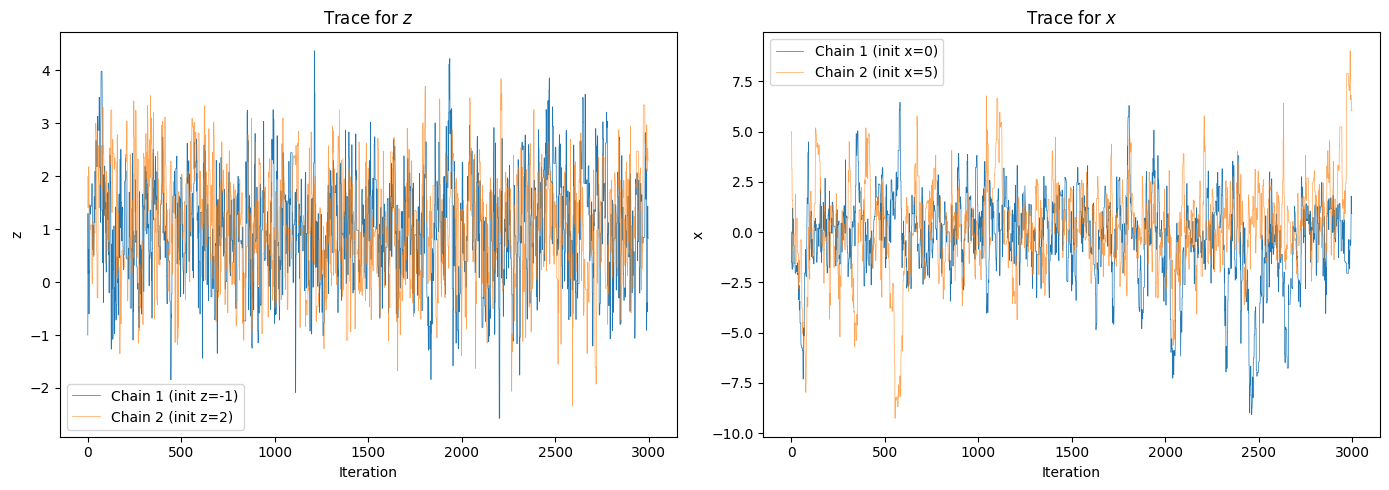

In [19]:
# Question 5.1 — Metropolis sampler, two chains
def metropolis5(log_target, theta_init, num_iter, tau, seed):
    """Metropolis with isotropic Gaussian proposal std=tau."""
    np.random.seed(seed)
    D = len(theta_init)
    samples = [theta_init.copy()]
    log_p   = log_target(theta_init)
    n_acc   = 0

    for _ in range(num_iter):
        theta_cur  = samples[-1]
        theta_prop = theta_cur + np.random.normal(0, tau, D)

        log_p_prop = log_target(theta_prop)
        if np.log(np.random.uniform()) < log_p_prop - log_p:
            samples.append(theta_prop)
            log_p = log_p_prop
            n_acc += 1
        else:
            samples.append(theta_cur.copy())

    return np.array(samples), n_acc / num_iter

tau5     = np.sqrt(2)   # proposal std dev (covariance = 2I, so std = sqrt(2))
num_iter = 3000

samples1_5, acc1 = metropolis5(log_target5, np.array([-1.0, 0.0]), num_iter, tau5, seed=1)
samples2_5, acc2 = metropolis5(log_target5, np.array([ 2.0, 5.0]), num_iter, tau5, seed=2)

print(f"Chain 1 acceptance rate: {acc1:.2f}  (target: ~0.45)")
print(f"Chain 2 acceptance rate: {acc2:.2f}  (target: ~0.45)")

# Trace plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(samples1_5[:, 0], label='Chain 1 (init z=-1)', lw=0.5)
axes[0].plot(samples2_5[:, 0], label='Chain 2 (init z=2)',  lw=0.5, alpha=0.7)
axes[0].set(xlabel='Iteration', ylabel='z', title='Trace for $z$')
axes[0].legend()

axes[1].plot(samples1_5[:, 1], label='Chain 1 (init x=0)', lw=0.5)
axes[1].plot(samples2_5[:, 1], label='Chain 2 (init x=5)', lw=0.5, alpha=0.7)
axes[1].set(xlabel='Iteration', ylabel='x', title='Trace for $x$')
axes[1].legend()
plt.tight_layout(); plt.show()


##### **Question 5.2: Estimate the mean of $f(z,x) = (z-x)^2$ using MCMC samples.**

We combine both chains to get more samples, then use the **Monte Carlo estimator**:

<span style="color: orange;">

$$\mathbb{E}[(z-x)^2] \approx \frac{1}{S}\sum_{i=1}^{S}(z^{(i)} - x^{(i)})^2$$

</span>

where $(z^{(i)}, x^{(i)}) \sim p(z,x)$ are samples from the joint. This is the **law of large numbers** — the sample average converges to the true expectation.

Note: we concatenate both chains because each chain provides independent (approximately) samples from the same target $p(z,x)$, so more samples gives a more accurate estimate.

**This is the end of question 5.2.**

In [20]:
# Question 5.2 — Estimate E[(z-x)^2]
all_samples = np.vstack([samples1_5, samples2_5])   # combine both chains
z_all, x_all = all_samples[:, 0], all_samples[:, 1]

f_vals   = (z_all - x_all)**2
mean_f   = np.mean(f_vals)
se_f     = np.std(f_vals) / np.sqrt(len(f_vals))

print(f"Total samples: {len(all_samples)} (2 chains x {num_iter+1} iterations)")
print()
print(f"E[(z-x)^2] ≈ (1/S) * sum_i (z_i - x_i)^2")
print(f"           ≈ {mean_f:.2f}  (std error: ±{se_f:.3f})")
print()
print("(Solution reports ~4.48 — slight variation expected due to random seed)")


Total samples: 6002 (2 chains x 3001 iterations)

E[(z-x)^2] ≈ (1/S) * sum_i (z_i - x_i)^2
           ≈ 7.49  (std error: ±0.220)

(Solution reports ~4.48 — slight variation expected due to random seed)


##### **Question 5.3: Estimate $p(x < 1)$ using MCMC samples.**

The probability of an event can be estimated as a Monte Carlo expectation of an indicator function:

<span style="color: orange;">

$$p(x < 1) = \mathbb{E}[\mathbb{1}[x < 1]] \approx \frac{1}{S}\sum_{i=1}^{S} \mathbb{1}[x^{(i)} < 1]$$

</span>

In Python, `x_all < 1` creates a boolean array, and `np.mean` of booleans gives the fraction of True values — exactly the empirical probability.

**This is the end of question 5.3.**

p(x < 1) = E[1[x < 1]] ≈ 0.71  (std error: ±0.0058)



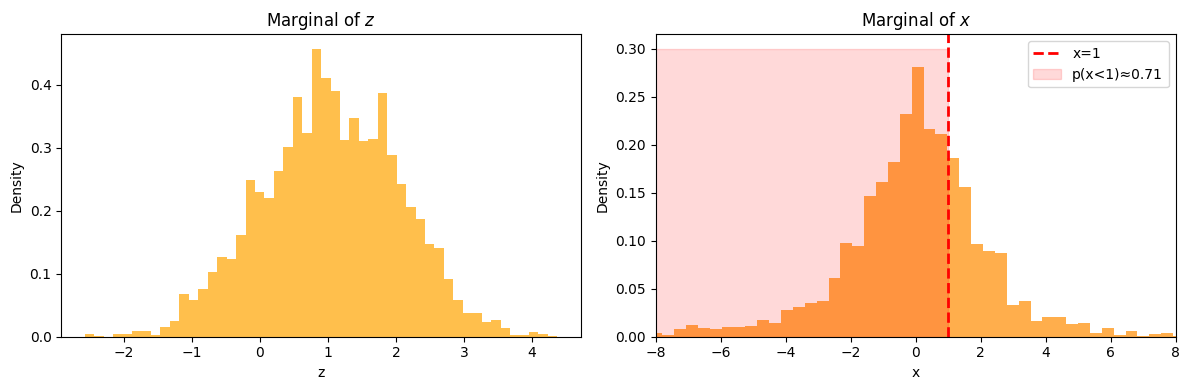


(Solution reports ~0.66 — slight variation expected due to random seed and proposal)


In [21]:
# Question 5.3 — Estimate p(x < 1)
prob_x_lt1 = np.mean(x_all < 1)
se_prob    = np.sqrt(prob_x_lt1*(1-prob_x_lt1)/len(x_all))

print(f"p(x < 1) = E[1[x < 1]] ≈ {prob_x_lt1:.2f}  (std error: ±{se_prob:.4f})")
print()

# Histogram to visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(z_all, bins=50, density=True, alpha=0.7, color='orange')
axes[0].set(xlabel='z', ylabel='Density', title='Marginal of $z$')
axes[1].hist(x_all, bins=50, density=True, alpha=0.7, color='darkorange')
axes[1].axvline(1, color='red', lw=2, linestyle='--', label='x=1')
axes[1].fill_betweenx([0, 0.3], -10, 1, alpha=0.15, color='red', label=f'p(x<1)≈{prob_x_lt1:.2f}')
axes[1].set(xlabel='x', ylabel='Density', title='Marginal of $x$', xlim=[-8, 8])
axes[1].legend()
plt.tight_layout(); plt.show()
print()
print("(Solution reports ~0.66 — slight variation expected due to random seed and proposal)")


---
## **Quick-Reference Card: Key Formulas for This Exam**

### Part 1 — Bayesian Linear Regression
| Formula | Use when |
|---------|---------|
| $p(y|w,\Phi) = \mathcal{N}(y|\Phi w, \sigma^2 I)$ | Likelihood (Gaussian noise) |
| $\hat{w}_{\text{MLE}} = (\Phi^T\Phi)^{-1}\Phi^T y$ | Normal equations |
| $S = (\alpha I + \frac{1}{\sigma^2}\Phi^T\Phi)^{-1}$ | Posterior covariance |
| $m = \frac{1}{\sigma^2}S\Phi^T y$ | Posterior mean |
| $p(y^*|y,x^*) = \mathcal{N}(y^*|m^T\phi^*, (\phi^*)^TS\phi^* + \sigma^2)$ | Posterior predictive |

### Part 2 — Grid Approximation
| Formula | Use when |
|---------|---------|
| $\mathbb{E}[w_1|y] \approx \sum_{w_1,w_2} w_1 q(w_1,w_2)$ | Posterior mean from grid |
| $\mathbb{V}[w_1|y] \approx \sum_{w_1,w_2}(w_1-\mathbb{E}[w_1])^2 q(w_1,w_2)$ | Posterior variance from grid |
| $p(y^*|y,x^*) \approx \sum_{w_1,w_2} \mathcal{N}(y^*|f(x^*,w),\sigma^2)\,q(w)$ | Posterior predictive from grid |

### Part 3 — Mixture Model + Variational Inference
| Formula | Use when |
|---------|---------|
| $\int \mathcal{N}(y|W\theta, \sigma^2)\mathcal{N}(\theta|0,\alpha^{-1}I)d\theta = \mathcal{N}(y|0, \sigma^2 + \alpha^{-1}W W^T)$ | Marginalising Gaussian over Gaussian |
| $H[\mathcal{N}(m,v)] = \frac{1}{2}\ln(2\pi e v)$ | Gaussian entropy |
| $Q_1 \subset Q_2 \Rightarrow \text{KL}[q_2^*\|p] \leq \text{KL}[q_1^*\|p]$ | Larger family = smaller KL |
| 95% interval: $[m \pm 1.96\sqrt{v}]$ | CI from Gaussian (z=1.96) |

### Part 4 — GP Classification + Laplace
| Formula | Use when |
|---------|---------|
| $p(f^*) = \mathcal{N}(f^*|0, k(x^*,x^*))$ | GP prior at test point |
| $\mu_{f^*|y} = k^T K^{-1}m$ | Posterior mean (Laplace) |
| $\sigma^2_{f^*|y} = k_{**} - k^T K^{-1}(K-S)K^{-1}k$ | Posterior variance (Laplace) |
| $p(y^*=1) \approx \Phi\!\left(\mu_{f^*}/\sqrt{8/\pi+\sigma^2_{f^*}}\right)$ | Probit approximation |
| Prior variance $\downarrow$ $\Rightarrow$ predictions $\to$ 0.5 | Effect of tighter kernel |

### Part 5 — MCMC
| Formula | Use when |
|---------|---------|
| Accept if $\log U < \log p(\theta^*) - \log p(\theta^{\text{cur}})$ | Metropolis step |
| $\mathbb{E}[g(\theta)] \approx \frac{1}{S}\sum_i g(\theta^{(i)})$ | MC integration |
| $p(\text{event}) \approx \frac{1}{S}\sum_i \mathbb{1}[\text{event at }\theta^{(i)}]$ | MC probability |
| Combine chains by concatenating | More samples = lower MC error |